# Configuring Slurm Job on the fly

All versions will share the following parameter definitions

* 

## Blood Vessels

## All Tissue

## Simulate AAV Injection

We need to generate volumes for NAOMi that have different densities of neurons. The purpose of this is to model the transfection efficiency of the AAV delivered fluorescent indicator. After administration, only a few neurons will fluoresce, but as more time passes, more neurons will express the protein. So when you sample on different days, you should expect to see different numbers of neurons.

We can model this system with a random variable that represents the amount of delivered viral load to each of the cells. This could be a Poisson random variable. We'll say that given the local concentration of viral vector, the chances of a single vector being delivered to a cell is known.

$$
P(Y=y | c(x)) \sim \text{Poisson}(K \cdot c(x))
$$

We'll assume that the concentration of the vector has a Gaussian distribution and does not change significantly with time. Therefore, for a point that is distance $r$ from the injection location, the concentration will be

$$
C(r) = C_0 \cdot e^{-\frac{r^2}{\sigma^2}}
$$

Given these two pieces of information, we now have a spatial distribution of the initial genetic content in each of the neurons. Next, we can calculate the fluorescence some time later using the Hill equation

$$
F(t, c_0) = 
$$

So the full process with go like this

1. Obtain the location of a given neuron's soma. Calculate its distance to the injection site
2. Calculate the dose of the vector that the neuron receives
3. Sample the distribution 

In [11]:
from scipy.stats import poisson
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Concentration
N_gc = (0.1e-3) * (10e9)    # Injection volume (1 uL) x AAV Density (gc/mL)
sigma = 200                 # um
KD = N_gc / (sigma * np.sqrt(2 * np.pi))

KD

np.float64(1994.7114020071635)

In [13]:
from caveclient import CAVEclient

client = CAVEclient('minnie65_public')
client.version = 1300

# Select excitatory neurons around the injection site and find the distribution of soma size
ct_df = client.materialize.tables.aibs_metamodel_celltypes_v661(classification_system='excitatory_neuron') \
    .query(
        split_positions=True, 
        desired_resolution=[1,1,1],
        # select_column=['id', 'volume', 'cell_type', 'pt_position']
        ) \
    .drop_duplicates('pt_root_id', keep=False) \
    .rename(columns={
        'id' : 'nucleus_id',
        'pt_position_x': 'x',
        'pt_position_y': 'y',
        'pt_position_z': 'z'
        }) \
    [['nucleus_id', 'volume', 'cell_type', 'x', 'y', 'z']]
ct_df.head()

,nucleus_id,volume,cell_type,x,y,z
0,18312,221.584747,23P,309568,421120,706000
1,255686,297.846039,23P,703040,505920,620160
3,204945,250.471878,6P-CT,571968,967936,768160
4,19116,301.426117,23P,290304,434624,811640
5,524777,316.821014,4P,1188160,651456,802200


In [14]:
ct_df['r'] = np.power(ct_df['volume'] * 3/(4*np.pi), 1/3)
ct_df['sa'] = np.pow(ct_df['r'], 2) * 4 * np.pi
ct_df

,nucleus_id,volume,cell_type,x,y,z,r,sa
0,18312,221.584747,23P,309568,421120,706000,3.753909,177.083221
1,255686,297.846039,23P,703040,505920,620160,4.142868,215.681091
3,204945,250.471878,6P-CT,571968,967936,768160,3.910421,192.157272
4,19116,301.426117,23P,290304,434624,811640,4.159401,217.405945
5,524777,316.821014,4P,1188160,651456,802200,4.22904,224.746796
...,...,...,...,...,...,...,...,...
64189,172290,251.537323,6P-CT,499840,1002624,899320,3.915957,192.701813
64190,408238,252.318344,6P-CT,943360,1017536,939240,3.920006,193.10051
64191,309459,229.114517,6P-IT,726720,1007488,984800,3.795958,181.07254
64193,303035,497.987762,5P-ET,726528,775296,867440,4.917111,303.829529


In [15]:
inj_site_x, inj_site_y, inj_site_z = (681280, 531968, 809000)
sel_x = (ct_df['x'] > (inj_site_x - 0.25e3*sigma)) & (ct_df['x'] < (inj_site_x + 0.25e3*sigma))
sel_y = (ct_df['y'] > (inj_site_y - 0.25e3*sigma)) & (ct_df['y'] < (inj_site_y + 0.25e3*sigma))
sel_z = (ct_df['z'] > (inj_site_z - 0.25e3*sigma)) & (ct_df['z'] < (inj_site_z + 0.25e3*sigma))
local_ct_df = ct_df[sel_x & sel_y & sel_z]

len(local_ct_df)

205

212.00023


(np.float32(212.00023), np.float32(23.647713))

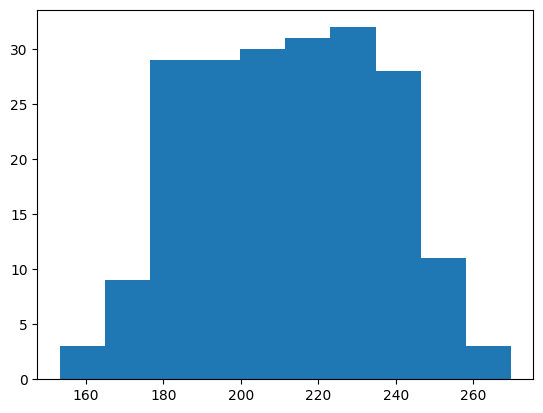

In [16]:
plt.hist(local_ct_df['sa'])
print(local_ct_df['sa'].mean())

soma_mean = local_ct_df['sa'].mean()
soma_sd = local_ct_df['sa'].std()

soma_mean, soma_sd

In [17]:
# From literature, C(r ~ 0) * soma_size * p should be around 50
# p = 0.005 # 1e-5
p = 10 / (KD * local_ct_df['sa'].mean())
p

np.float64(2.3647411022637504e-05)

In [18]:
p * KD * local_ct_df['sa'].mean()

np.float64(10.0)

In [19]:
# Fluorescence
n = 1         # Hill Constant
H = 24 * 5     # 10 days, in hours units
KF = 100 # (KD*p)/2
FMax = 100
FN = 10

In [20]:
t = 24*1
Dmin = KF / ((FMax/FN)*(np.pow(t,n)/(np.pow(H,n)+np.pow(t,n))) - 1)
Dmin

np.float64(150.00000000000003)

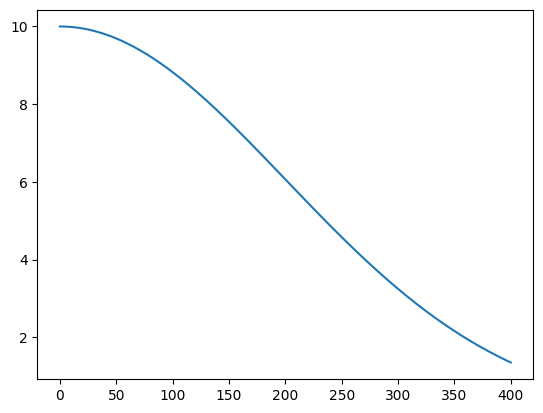

In [21]:
r = np.linspace(0, 2*sigma, int(2*sigma/0.1))
local_gc = soma_mean * KD * np.exp(-(np.pow(r, 2))/(2*np.pow(sigma, 2))) * p
plt.plot(r, local_gc)

In [22]:
r = np.linspace(0, 2*sigma, int(200/0.1))
results = np.zeros_like(r)

for idx, rr in enumerate(r):
    local_gc = soma_mean * KD * np.exp(-(np.pow(rr, 2))/(2*np.pow(sigma, 2)))
    moi = local_gc * p
    poi = poisson(moi)
    expectation = 1 - poi.cdf(Dmin)
    results[idx] = expectation

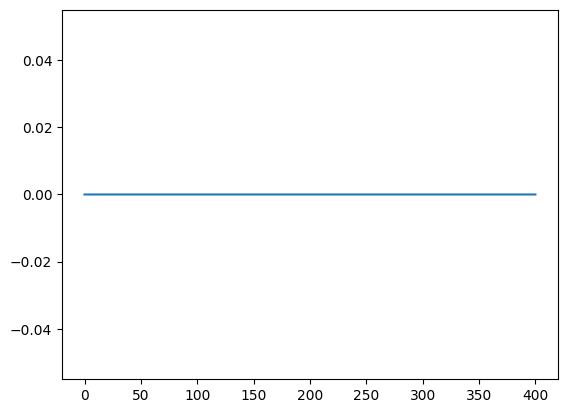

In [23]:
plt.plot(r, results)

To find the "number of new neurons per um away"
Calculate the total number of neurons at radius r from injection site
Integral of the product of the expectation and the volume of a (shell at radius r with thickness dr)
Differentiate with respect to r

However, this would require a continuous function of the expectation wrt r, but since we're using a poisson, it's discrete
Should really consider finding a continuous rv to replace it with
Can we just sub in a gamma for the factorial?

Would still like to find the expectation over time (not just distance)
Would still like to plot the distribution of transfection to show that some neurons are definitely below the limit of detection

Is there actually an error since Dmin is less than 1? Because poissons only operate on the integers?
Double check the equation for Dmin

Should we actually model the diffusion of the virus? Gemini is giving conflicting answers

In [24]:
t = 24*np.arange(1, 31)
r = np.linspace(0, sigma, int(1.5*sigma/0.1))
results = np.zeros((len(t), len(r)))

for ii, tt in enumerate(t):
    Dmin = KF / ((FMax/FN)*(np.pow(tt,n)/(np.pow(H,n)+np.pow(tt,n))) - 1)

    for jj, rr in enumerate(r):
        if Dmin <= 0:
            results[ii, jj] = 0
            continue

        local_gc = soma_mean * KD * np.exp(-(np.pow(rr, 2))/(2*np.pow(sigma, 2)))
        moi = local_gc * p
        poi = poisson(moi)
        expectation = 1 - poi.cdf(Dmin)
        results[ii, jj] = expectation

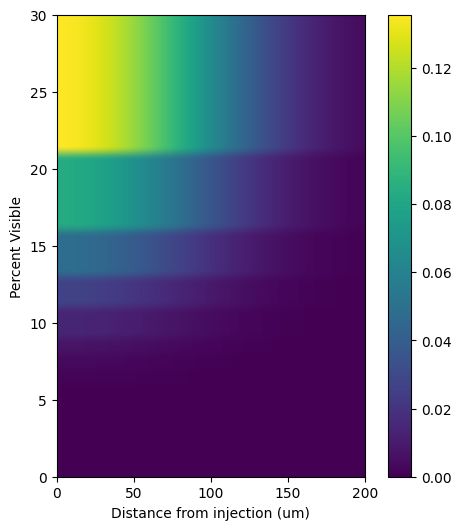

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))

extent = [0, max(r), 0, max(t)/24]  # time vs channel
im = ax.imshow(results, cmap='viridis', origin='lower', extent=extent)

ax.set_aspect(len(r)/(10*len(t)))   # square axes visually but data still interpretable
plt.colorbar(im, ax=ax)
plt.xlabel('Distance from injection (um)')
plt.ylabel('Percent Visible')
plt.show()

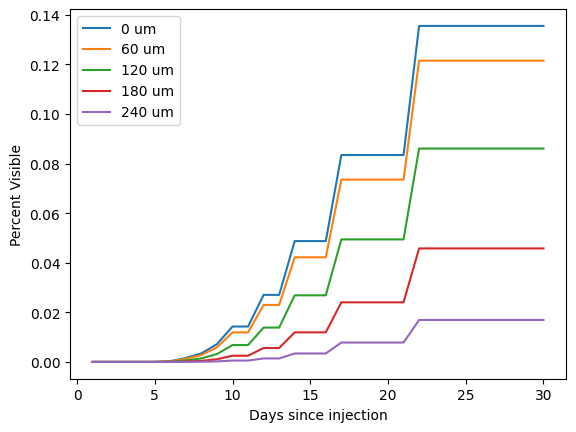

In [41]:
fig, ax = plt.subplots()
r_test = np.arange(0, len(r), len(r)/5, dtype=np.int32)
ax.plot(t/24, results[:,r_test])

ax.set_xlabel('Days since injection')
ax.set_ylabel('Percent Visible')
ax.legend(labels=list(map(lambda rr: f'{rr:.0f} um', r_test/10)))

In [27]:
import json

dosage = None
with open('../rockfish/example-inj/dosage.json', 'r') as f:
    dosage = json.load(f)

plt.hist(dosage.items(), bins=50)

FileNotFoundError: [Errno 2] No such file or directory: '../rockfish/example-inj/dosage.json'